In [1]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

# Load Data

In [2]:
dataset_path = 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN'] #'GFA', 'PPA', 'FPR', 'PPE', 'FPA', 'OAE', 'EOP', 'FNP', 'FPP'
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


# Compute Fairness
An addition is made to compute_fairness_metrics. A count_group dictionary is made specifying the subgroup and the "length" which is TN + FP + FN + TP

## Classifier and Predictions

## Functions

### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

X_train, X_val, X_test: features to train, validate, and evaluate the model

y_train, y_val, y_test: corresponding labels

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, weights
2. Model 2: Fit on training (with weights) → Predict on test (unseen)

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

Compute the previous functions, plus the confusion matrix for...

## Build the dictionaries 

For X and y training, testing, prediction, fairness metrics and group counts, for each subgroup. 

In the form {Subgroup: data}

Using the functions above

In [3]:
pairs_dict= {}
fairness_metrics_dict= {}
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
y_pred = {}   # Predictions on validation set
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}
group_counts= {}
s= []
model_baseline= {}

for i in range(1,len(protected_attributes)+1):
  pairs_dict[i] = ['-'.join(pair) for pair in combinations(protected_attributes, i)]
#print(pairs_dict)

for i in range(1, len(protected_attributes)+1):
  df=pd.read_csv(dataset_path)
  for sensible_attribute in pairs_dict[i]:
    s = sensible_attribute.split('-')
    print(s)
    if len(s)>1:
      df=pd.read_csv(dataset_path)
      df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
      df = df.drop(columns=s)
    
    # Updated to include X_test and y_test
    (y_train[sensible_attribute], X_train[sensible_attribute], 
     X_val[sensible_attribute], y_val[sensible_attribute], y_pred[sensible_attribute],
     X_test[sensible_attribute], y_test[sensible_attribute],
     fairness_metrics_dict[sensible_attribute], group_counts[sensible_attribute], model_baseline[sensible_attribute]) = get_test_pred_fairness(
        df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping, target_variable_labels)

['age']
age
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
['sex']
sex
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
['race']
race
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
['edu']
edu
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
['age', 'sex']
age-sex
Precision: 0.7214076246334311, Recall: 0.6175732217573222, Accuracy: 0.8480753480753481, F1: 0.6654643823264202
['age', 'race']
age-race
Precision: 0.7179236043095005, Recall: 0.6133891213389121, Accuracy: 0.8464373464373465, F1: 0.6615523465703971
['age', 'edu']
age-edu
Precision: 0.7232580961727183, Recall: 0.6167364016736402, Accuracy: 0.8484848484848485, F1: 0.6657633242999097
['sex', 'race']
sex-race
Precision: 0.7216796875, Recall: 0.6184100418410042, Accuracy: 0.84828

In [4]:
# Prepare df with sex-race column for evaluation
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df = pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

# Evaluate Model 1 (baseline) on TEST set
y_pred_test_baseline, performance_baseline, fairness_baseline, counts_baseline = evaluate_model_on_test(
    model_baseline['sex-race'], df, 'sex-race', 
    X_test['sex-race'], y_test['sex-race'],
    fair_metrics, mapping, dataset_path
)


# print(f"Performance: Precision={performance_baseline[0]:.4f}, Recall={performance_baseline[1]:.4f}, Accuracy={performance_baseline[2]:.4f}, F1={performance_baseline[3]:.4f}")
# print(f"Fairness Metrics: {fairness_baseline}")
print(f"Group Counts: {counts_baseline}")

Precision: 0.7469194312796209, Recall: 0.6533996683250415, Accuracy: 0.8597748208802457, F1: 0.6970367094206104
Group Counts: {'01': 1323, '00': 287, '11': 2992, '10': 283}


In [5]:
fairness_metrics_dict['sex-race']['FPN']

{'01': 0.2564102564102564,
 '00': 0.25,
 '11': 0.42387543252595156,
 '10': 0.21052631578947367}

ORIGINAL: FPN {'01': 0.2374429223744292, '00': 0.09090909090909091, '11': 0.43541102077687444, '10': 0.20512820512820512}

NOW: FPN {'01': 0.2564102564102564, '00': 0.25, '11': 0.42387543252595156, '10': 0.21052631578947367}

While the rest of them change only very slightly, 00 changes significantly, massively even. 



In [6]:
print(group_counts['sex-race'])

{'01': 1403, '00': 246, '11': 2937, '10': 298}


# Compute Penalty

Every subgroup and attribute combination, for each metric.

In [7]:
values= {}
penalties_across_metrics= {}
for m in fair_metrics:
  print(m)
  df=pd.read_csv(dataset_path)
  actual_values= {}
  predicted_values= {}
  penalties= {}
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      if len(s)==2:
        s1, s2 = sensible_attribute.split('-')
        # Build dictionary for attribute combinations. Form {attributes: {subgroup: value, s: v, s: v, ...}...}
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_2(fairness_metrics_dict, df,s1, s2, m)
        print(s1, s2, actual_values[sensible_attribute], predicted_values[sensible_attribute])

        # Build dictionary for penalty calculation of each attribute and subgroup combination. 
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      elif len(s)==3:
        s1, s2, s3 = sensible_attribute.split('-')
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_3(fairness_metrics_dict, df,s1, s2, s3, m)
        print(s1, s2, s3, actual_values[sensible_attribute], predicted_values[sensible_attribute])
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      elif len(s)==4:
        s1, s2, s3, s4 = sensible_attribute.split('-')
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_4(fairness_metrics_dict, df,s1, s2, s3, s4, m)
        print(s1, s2, s3, s4, actual_values[sensible_attribute], predicted_values[sensible_attribute])
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      
      values[m]= [actual_values, predicted_values]
      penalties_across_metrics[m]= penalties # The penalties dictionary itself didn't include m before
print(penalties)

#print(values['FPP'])


FPN
age sex {'00': 0.24324324324324326, '01': 0.16111111111111112, '10': 0.25287356321839083, '11': 0.5136986301369864} {'00': 0.20911528150134048, '01': 0.2505100884153253, '10': 0.32671957671957674, '11': 0.4404252864320202}
{'00': -16.320166320166326, '01': 35.68677727501256, '10': 22.602261622225324, '11': -16.63695204663865}
age race {'00': 0, '01': 0.1848341232227488, '10': 0.23076923076923078, '11': 0.4897959183673469} {'00': 0.19485385960529603, '01': 0.24756779134754706, '10': 0.2931924743308208, '11': 0.43141101499167833}
{'00': 100.0, '01': 25.339995878837826, '10': 21.290875116786037, '11': -13.533475351062794}
age edu {'00': 0.12698412698412698, '01': 0.1830065359477124, '10': 0.09444444444444444, '11': 0.6656976744186046} {'00': 0.13697560975609754, '01': 0.26727171698462676, '10': 0.17923564824768864, '11': 0.49500338524035203}
{'00': 7.294351738796177, '01': 31.527907998496232, '10': 47.307109178454205, '11': -34.48345895561317}
sex race {'00': 0.25, '01': 0.25641025641

In [8]:
m = 'FPN'  
print(penalties_across_metrics[m]['sex-race'])
print(fairness_metrics_dict['sex-race'][m])
print(group_counts['sex-race'])

{'00': -8.749999999999988, '01': 16.480862133036045, '10': 25.05675954592364, '11': -4.572201228919415}
{'01': 0.2564102564102564, '00': 0.25, '11': 0.42387543252595156, '10': 0.21052631578947367}
{'01': 1403, '00': 246, '11': 2937, '10': 298}


# Make the model using the sample weights

Evaluating performance metrics (Precision, Recall, Accuracy, F1)

Comparing the before and after of fairness metrics, for g=['sex-race'], m = 'fpn'. 

TRAIN on TRAIN

PREDICT on ~~TEST~~ VALIDATION (changed 2/12/2025 to perform computations of performance, metrics, etc. on the same set of data, so it can be compared fairly)

In [9]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [10]:
def model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights, model_type='GB'):
  """
  Model 2: Fit on training data (with sample weights computed from validation predictions)
           Predict on test set (unseen data)
  
  Parameters:
    X_train, y_train: Training data
    X_val, y_val: Validation data (now used to predict and compute metrics, performance on the same data, to make comparisons on the same data)
    X_test, y_test: Test data (unseen, WILL BE used for final evaluation)
    weights: Sample weights computed from validation set predictions
  """
  # TODO: implement final evaluation on test set
  # Note: weights were computed on validation set, then propagated to the training set based on group membership.
  
  
  if model_type=='GB':
    # Model 2: Fit on training, predict on val (unseen)
    model = GradientBoostingClassifier(random_state = 1234).fit(X_train['sex-race'], y_train['sex-race'], sample_weight=weights)
    y_pred_on_test = model.predict(X_test['sex-race'])
  elif model_type=='RF':
    model = RandomForestClassifier(random_state = 1234).fit(X_train['sex-race'], y_train['sex-race'], sample_weight=weights)
    y_pred_on_test = model.predict(X_test['sex-race'])
  elif model_type=='XGB':
    import xgboost as xgb
    # Convert string combinations to numeric codes for BOTH train and val
    X_train_numeric = X_train['sex-race'].copy()
    X_train_numeric['sex-race'] = X_train_numeric['sex-race'].astype('category').cat.codes
    
    X_test_numeric = X_test['sex-race'].copy()
    X_test_numeric['sex-race'] = X_test_numeric['sex-race'].astype('category').cat.codes
    
    model = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
    model.fit(X_train_numeric, y_train['sex-race'], sample_weight=weights)
    y_pred_on_test = model.predict(X_test_numeric)

  sensible_indexes = X_test['sex-race']['sex-race'].loc[list(X_test['sex-race'].index)]
  cm = confusion_matrix(y_test['sex-race'], y_pred_on_test, labels=[0,1])
  print(cm)

  precision, recall, accuracy, f1_score = performance_metrics(y_test['sex-race'], y_pred_on_test)

  fairness_metrics_dict_after={}
  count_groups_after= {}
  # Compute fairness metrics on VAL set predictions
  cm_dict = compute_cm_group(df, 'sex-race', sensible_indexes, y_pred_on_test, y_test['sex-race'], X_test['sex-race'], [0,1])
  for m in fair_metrics:
    fairness_metrics_dict_after[m], count_groups_after = compute_fairness_metrics_and_counts(cm_dict, m, 'sex-race', mapping, dataset_path)

  # print("Fairness metrics after:", fairness_metrics_dict_after)
  for k in fairness_metrics_dict_after[m].keys():
    a = fairness_metrics_dict[sensible_attribute][m][k]
    b = fairness_metrics_dict_after[m][k]
    diff = b - a
    # print(f"Group {k}: before={a}, after={b}, diff={diff}")

  return precision, recall, accuracy, f1_score

# Computing Weights - Functions

$w_i = 1 + \lambda * Penalty(g_i) $

# Generalizing for multiple fairness metrics

Note: flat group and nromal weight computation both may use FPN metric but yield different weights because they are computing different penalties. 

Note: flat group is currently able to calculate for multiple fairness metrics. Meanwhile, normal weight calculation is not because penalties_across_metrics currently only holds  values for the FPN metric. 

m = FPN

# Calculating and Implementing weights

Calculating the weights using the functions above

Comparing performance, fairness metrics

$w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [11]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

In [12]:
# Now we need weights for training samples to use with Model 2
# Propagate weights from validation to training based on group membership
train_df = X_train['sex-race'].copy()
weights_for_training = np.ones(len(train_df))
m = 'FPN'

# # Calculate average weight per group from validation set
# df['weight'] = weights
group_counts2 = train_df['sex-race'].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

lambda_ = 5.0
group_weights = {
    group: 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size)
    for group, penalty in penalties_across_metrics[m]['sex-race'].items()
}


# Assign weights to training samples based on their group
for i, (idx, row) in enumerate(train_df.iterrows()):
    group = row['sex-race']
    if group in group_weights:
        weights_for_training[i] = group_weights[group]

print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
weights_sized = weights_for_training

Training samples: 22792, Unique weights per group: {'00': 0.9607637394174201, '01': 1.3702222653073315, '10': 1.120627677251505, '11': 0.7713899385540293}


In [13]:
# Model 2: Fit on training with weights, predict on TEST (unseen)
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_sized)

[[3449  230]
 [ 445  761]]
Precision: 0.7679112008072654, Recall: 0.6310116086235489, Accuracy: 0.8618219037871033, F1: 0.6927628584433319


(0.7679112008072654,
 0.6310116086235489,
 0.8618219037871033,
 0.6927628584433319)

$w_i = 1 + \lambda * Penalty(g_i) $

In [14]:
# Now we need weights for training samples to use with Model 2
# Propagate weights from validation to training based on group membership
train_df = X_train['sex-race'].copy()
weights_for_training = np.ones(len(train_df))
m = 'FPN'

lambda_ = 1.0
group_weights = {
    group: 1 + lambda_ * (penalty / 100)
    for group, penalty in penalties_across_metrics[m]['sex-race'].items()
}


# Assign weights to training samples based on their group
for i, (idx, row) in enumerate(train_df.iterrows()):
    group = row['sex-race']
    if group in group_weights:
        weights_for_training[i] = group_weights[group]

print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
weights_notsized = weights_for_training

Training samples: 22792, Unique weights per group: {'00': 0.9125000000000001, '01': 1.1648086213303603, '10': 1.2505675954592363, '11': 0.9542779877108059}


In [15]:
# Model 2: Fit on training with weights, predict on TEST (unseen)
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_notsized)

[[3450  229]
 [ 449  757]]
Precision: 0.7677484787018256, Recall: 0.6276948590381426, Accuracy: 0.8612077789150461, F1: 0.6906934306569343


(0.7677484787018256,
 0.6276948590381426,
 0.8612077789150461,
 0.6906934306569343)

$w_i = 1 + \lambda * Penalty(g_i) $  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;   *WITH FAIRNESS METRICS*

With penalty computed, for different metrics

In [16]:
# df=X_test['sex-race'].copy()
df_val = X_val['sex-race'].copy()
list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']

# Case for fpn - propagating for training set
weights_per_metric = {}
train_df = X_train['sex-race'].copy()
for m in list_of_metrics:
    metric_penalties = compute_sample_weights_flat_group_allmetrics(
        df_val, 
        y_val[sensible_attribute], 
        y_pred[sensible_attribute], 
        'sex-race', 
        focus_on=m, 
        lambda_=1.0
        )

    print(f"Metric: {m}, Penalties: {metric_penalties}")
    weights_for_training = np.ones(len(train_df))
    
    lambda_ = 1.0
    group_weights = {
        group: 1 + lambda_ * (penalty / 100)
        for group, penalty in metric_penalties.items()
    }
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row['sex-race']
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
            
    weights_per_metric[m] = weights_for_training

Metric: fpn, Penalties: {'11': np.float64(-5.246343189682295), '01': np.float64(20.904977375565608), '10': np.float64(35.05882352941176), '00': np.float64(-1.7857142857142914)}
Metric: fne, Penalties: {'11': np.float64(3.537763989977333), '01': np.float64(-10.02778260114603), '10': np.float64(-16.81715575620767), '00': np.float64(0.5813953488372111)}
Metric: ppe, Penalties: {'11': np.float64(-27.49268098281756), '01': np.float64(59.06674201521514), '10': np.float64(44.79602147188577), '00': np.float64(60.3988603988604)}
Metric: fpr, Penalties: {'11': np.float64(-0.46566583263832123), '01': np.float64(1.1890805560207678), '10': np.float64(7.77647518561938), '00': np.float64(4.761904761904766)}
Metric: fpa, Penalties: {'11': np.float64(-17.12393198074087), '01': np.float64(32.99081038956868), '10': np.float64(-12.145273252614498), '00': np.float64(60.26968927105725)}
Metric: eop, Penalties: {'11': np.float64(5.063457854406135), '01': np.float64(-15.99099807073449), '10': np.float64(-25.1

In [17]:
performance_per_metric = {}
list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']

for m in list_of_metrics:
    performance_per_metric[m] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_per_metric[m])

[[3447  232]
 [ 447  759]]
Precision: 0.7658930373360242, Recall: 0.6293532338308457, Accuracy: 0.8610030706243603, F1: 0.6909421939007738
[[3454  225]
 [ 448  758]]
Precision: 0.7711088504577823, Recall: 0.6285240464344942, Accuracy: 0.8622313203684749, F1: 0.6925536774783005
[[3447  232]
 [ 453  753]]
Precision: 0.7644670050761422, Recall: 0.6243781094527363, Accuracy: 0.8597748208802457, F1: 0.6873573710634413
[[3451  228]
 [ 448  758]]
Precision: 0.768762677484787, Recall: 0.6285240464344942, Accuracy: 0.8616171954964176, F1: 0.6916058394160584
[[3446  233]
 [ 445  761]]
Precision: 0.7655935613682092, Recall: 0.6310116086235489, Accuracy: 0.8612077789150461, F1: 0.6918181818181818
[[3451  228]
 [ 448  758]]
Precision: 0.768762677484787, Recall: 0.6285240464344942, Accuracy: 0.8616171954964176, F1: 0.6916058394160584
[[3447  232]
 [ 448  758]]
Precision: 0.7656565656565657, Recall: 0.6285240464344942, Accuracy: 0.8607983623336745, F1: 0.6903460837887068
[[3450  229]
 [ 445  761]]
Pr

# JSD - Jensen-Shannon Divergence

### Resampling

Resampling the dataset based on the weights, to reflect an effect of the weights on the dataset.

Added 3/12/2025: generalization for all the weights available (for weights based on metrics, only using fpn currently)

In [18]:
import numpy as np

# Training DataFrame
original_train_df = X_train['sex-race'].copy()

# Use the first weights formula computed earlier (change if using another formula)
sample_weights = {
    'Weights sized': weights_sized,
    'Weights not sized': weights_notsized,
    'Weights fpn': weights_per_metric['ppe'],
}
# sample_weights = weights_notsized

# Normalize weights to probabilities for resampling
# probs = sample_weights / sample_weights.sum()
probs = {}
for key, weights in sample_weights.items():
    probs[key] = weights / np.sum(weights)

# Resample with replacement based on weights
n_samples = len(original_train_df)  # equal to the training df

# Overrepresent rows with higher weights, underrepresent those with lower weights
np.random.seed(42)  # For reproducibility
# Randomly select indices based on computed probabilities, then create new df with rows based on those indices
# resampled_indices = np.random.choice(len(original_train_df), size=n_samples, replace=True, p=probs)
# resampled_train_df = original_train_df.iloc[resampled_indices].reset_index(drop=True)

resampled_train_df_dict = {}
for key, prob in probs.items():
    resampled_indices = np.random.choice(len(original_train_df), size=n_samples, replace=True, p=prob)
    resampled_train_df_dict[key] = original_train_df.iloc[resampled_indices].reset_index(drop=True)

# ============================================================
# PRINTS - TABLES TO COMPARE DISTRIBUTIONS BEFORE AND AFTER RESAMPLING
# ============================================================
for key, resampled_train_df in resampled_train_df_dict.items():

    print("\n", "-"*60, "WEIGHTS:", key, "-"*60)
    print("")
    print("=" * 60)
    print("ORIGINAL TRAINING SET - Group Distribution")
    print("=" * 60)
    original_dist = original_train_df[sensible_attribute].value_counts().sort_index() # # of samples per subgroup
    original_pct = (original_dist / len(original_train_df) * 100).round(2) # % of the total 
    for group in original_dist.index:
        print(f"  Group {group}: {original_dist[group]:5d} samples ({original_pct[group]:5.2f}%) | Weight: {group_weights.get(group, 1.0):.4f}")

    print("\n" + "=" * 60)
    print("RESAMPLED TRAINING SET - Group Distribution")
    print("=" * 60)
    resampled_dist = resampled_train_df[sensible_attribute].value_counts().sort_index()
    resampled_pct = (resampled_dist / len(resampled_train_df) * 100).round(2)
    for group in resampled_dist.index:
        print(f"  Group {group}: {resampled_dist[group]:5d} samples ({resampled_pct[group]:5.2f}%)")

    # print("\n" + "=" * 60)
    # print("CHANGE IN DISTRIBUTION")
    # print("=" * 60)
    # for group in original_dist.index:
    #     change = resampled_pct[group] - original_pct[group]
    #     print(f"  Group {group}: {change:+.2f}%")

# print(f"\nOriginal dataset size: {len(original_train_df)}")
# print(f"Resampled dataset size: {len(resampled_train_df)}")


 ------------------------------------------------------------ WEIGHTS: Weights sized ------------------------------------------------------------

ORIGINAL TRAINING SET - Group Distribution
  Group 00:  1250 samples ( 5.48%) | Weight: 1.5854
  Group 01:  6262 samples (27.47%) | Weight: 1.2353
  Group 10:  1342 samples ( 5.89%) | Weight: 0.7586
  Group 11: 13938 samples (61.15%) | Weight: 0.9031

RESAMPLED TRAINING SET - Group Distribution
  Group 00:  1210 samples ( 5.31%)
  Group 01:  8855 samples (38.85%)
  Group 10:  1499 samples ( 6.58%)
  Group 11: 11228 samples (49.26%)

 ------------------------------------------------------------ WEIGHTS: Weights not sized ------------------------------------------------------------

ORIGINAL TRAINING SET - Group Distribution
  Group 00:  1250 samples ( 5.48%) | Weight: 1.5854
  Group 01:  6262 samples (27.47%) | Weight: 1.2353
  Group 10:  1342 samples ( 5.89%) | Weight: 0.7586
  Group 11: 13938 samples (61.15%) | Weight: 0.9031

RESAMPLED TR

## Comparison between original and resampled datasets

Based on JSD

In [19]:
# Define which columns to compare (all columns or specific ones)
columns_to_compare = original_train_df.columns.tolist()

jsd_df = {}
for key, resampled_train_df in resampled_train_df_dict.items():
    jsd_df[key] = build_jsd_table(
        original_df=original_train_df,
        resampled_dfs={'Resampled': resampled_train_df},
        columns=columns_to_compare,
        bins=20
    )

# Summary statistics
# resampled_jsds = {}
# for key, jsd_table in jsd_df.items():
#     print("\n", "-"*60, "WEIGHTS:", key, "-"*60)
#     print("")
#     print("\n" + "=" * 70)
#     print("Jensen-Shannon Divergence between original and reweighted dataset")
#     print("=" * 70)
#     resampled_jsds[key] = jsd_table.loc['Resampled']
#     print(resampled_jsds[key].T.to_string())
#     print("-" * 37)
#     print(f"Mean JSD: {resampled_jsds[key].mean():.6f}")
#     print(f"Max JSD: {resampled_jsds[key].max():.6f} ({resampled_jsds[key].idxmax()})")
#     print(f"Min JSD: {resampled_jsds[key].min():.6f} ({resampled_jsds[key].idxmin()})")

## JSD Comparison Plots

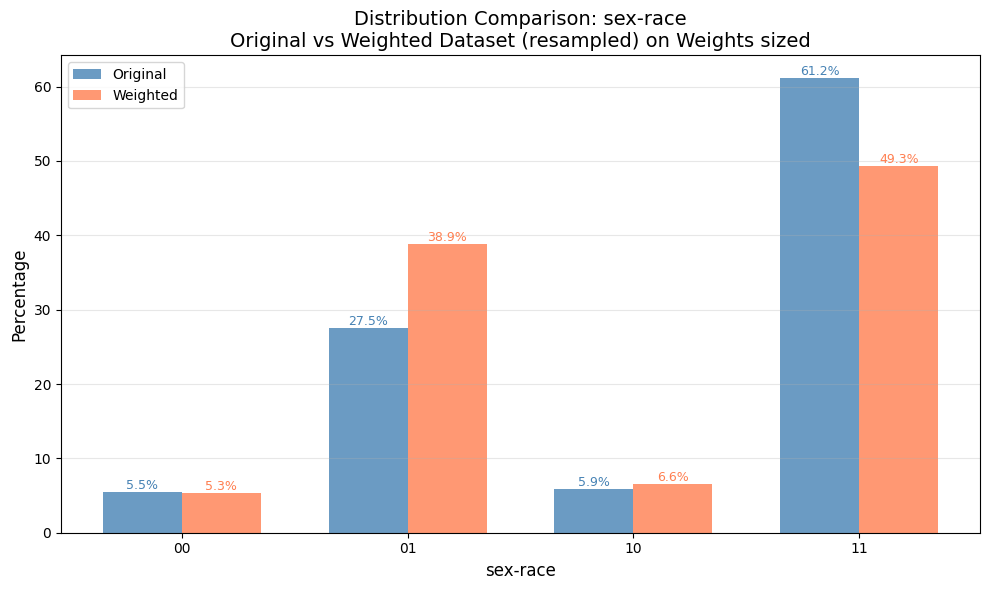

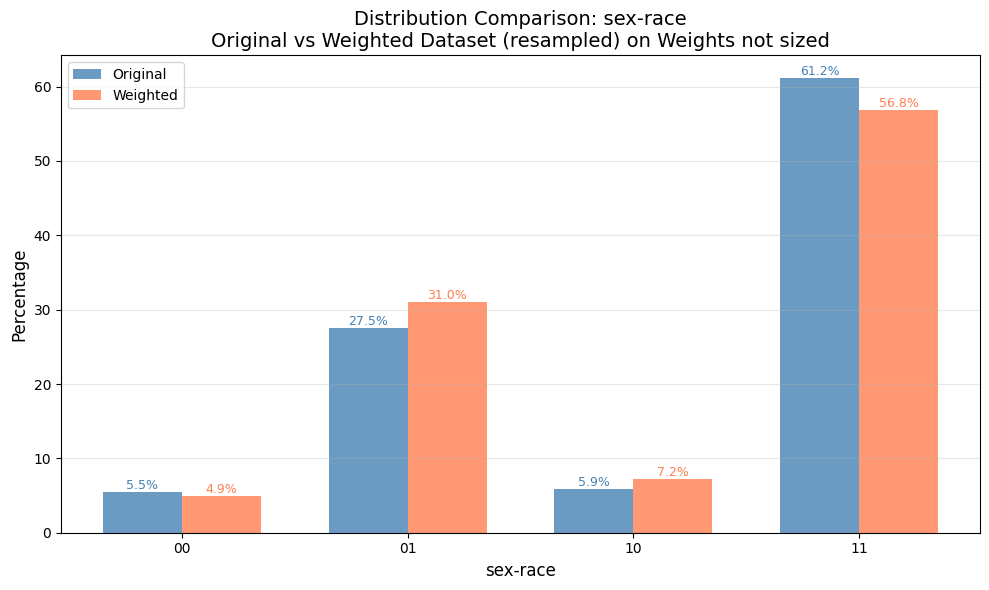

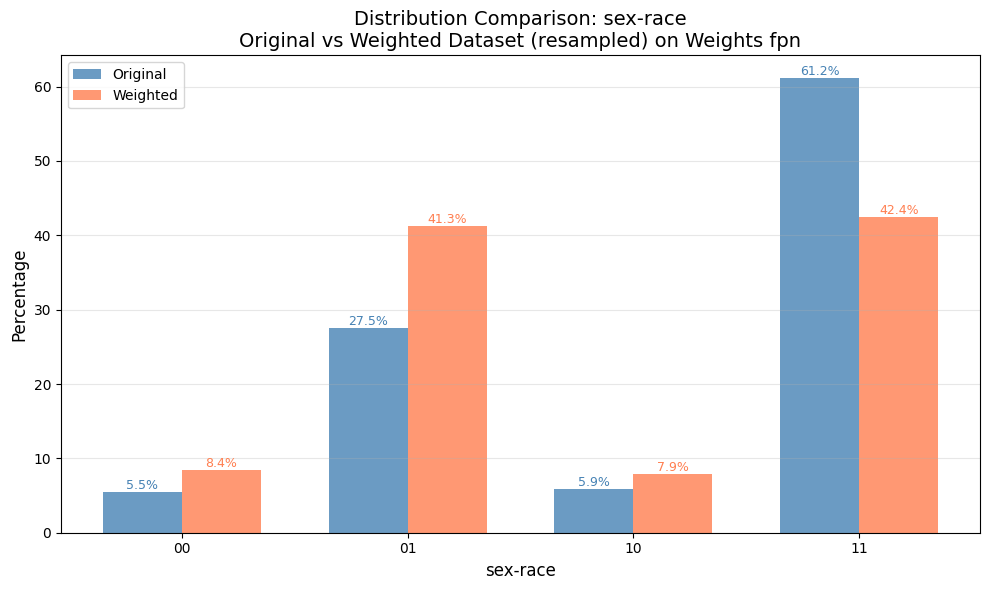

In [20]:
for key, resampled_train_df in resampled_train_df_dict.items():
    plot_distribution_comparison(original_train_df, resampled_train_df, sensible_attribute, key)

On harmonic mean

00: female, Amer-Black-Other | PREVPENALTY: 53.912

01: female, Asian-White | PREVPENALTY: 16.913

10: male, Amer-Black-Other | PREVPENALTY: 18.191

11: male, Asian-White | PREVPENALTY: -5.27

In [21]:
penalties_across_metrics['FPN']['sex-race'] # FIX THIS ASAP. See if something changes in the JSD. EXCELLENT approximation for all of them except 00, why?

{'00': -8.749999999999988,
 '01': 16.480862133036045,
 '10': 25.05675954592364,
 '11': -4.572201228919415}

In [22]:
"""
! - More correct according to OG
* 

Flat group penalties
Metric: fpn, Penalties: {'11': np.float64(-5.246343189682295), '01': np.float64(20.904977375565608), '10': np.float64(35.05882352941176), '00': np.float64(-1.7857142857142914)}
Metric: fne, Penalties: {'11': np.float64(3.537763989977333), '01': np.float64(-10.02778260114603), '10': np.float64(-16.81715575620767), '00': np.float64(0.5813953488372111)}
! Metric: ppe, Penalties: {'11': np.float64(-27.49268098281756), '01': np.float64(59.06674201521514), '10': np.float64(44.79602147188577), '00': np.float64(60.3988603988604)}
Metric: fpr, Penalties: {'11': np.float64(-0.46566583263832123), '01': np.float64(1.1890805560207678), '10': np.float64(7.77647518561938), '00': np.float64(4.761904761904766)}
Metric: fpa, Penalties: {'11': np.float64(-17.12393198074087), '01': np.float64(32.99081038956868), '10': np.float64(-12.145273252614498), '00': np.float64(60.26968927105725)}
Metric: eop, Penalties: {'11': np.float64(5.063457854406135), '01': np.float64(-15.99099807073449), '10': np.float64(-25.175470459477207), '00': np.float64(4.263565891472876)}
! Metric: fpp, Penalties: {'11': np.float64(-19.6770436747454), '01': np.float64(51.870361226375515), '10': np.float64(39.57415373655916), '00': np.float64(57.54936120789779)}
Metric: fnp, Penalties: {'11': np.float64(-9.688516313855336), '01': np.float64(23.53408985505881), '10': np.float64(-24.139865694691604), '00': np.float64(58.53658536585366)}

"""

"\n! - More correct according to OG\n* \n\nFlat group penalties\nMetric: fpn, Penalties: {'11': np.float64(-5.246343189682295), '01': np.float64(20.904977375565608), '10': np.float64(35.05882352941176), '00': np.float64(-1.7857142857142914)}\nMetric: fne, Penalties: {'11': np.float64(3.537763989977333), '01': np.float64(-10.02778260114603), '10': np.float64(-16.81715575620767), '00': np.float64(0.5813953488372111)}\n! Metric: ppe, Penalties: {'11': np.float64(-27.49268098281756), '01': np.float64(59.06674201521514), '10': np.float64(44.79602147188577), '00': np.float64(60.3988603988604)}\nMetric: fpr, Penalties: {'11': np.float64(-0.46566583263832123), '01': np.float64(1.1890805560207678), '10': np.float64(7.77647518561938), '00': np.float64(4.761904761904766)}\nMetric: fpa, Penalties: {'11': np.float64(-17.12393198074087), '01': np.float64(32.99081038956868), '10': np.float64(-12.145273252614498), '00': np.float64(60.26968927105725)}\nMetric: eop, Penalties: {'11': np.float64(5.063457

In [23]:
import matplotlib.pyplot as plt

for key, resampled_jsd in resampled_jsds.items():
    plot_jsd_bar_chart(resampled_jsd, sensible_attribute, key)

NameError: name 'resampled_jsds' is not defined

The sensitive attribute 'sex-race' has the highest JSD (0.008589), which is expected since reweighting intentionally shifts its distribution (changes samples) for fairness.

Mean JSD lower than 0.1 means the datasets are still pretty similar. We don't want them to be too dissimilar otherwise we're changing it too much. Objective: make the dataset fair with as low a JSD as possible. The JSD metric can then allow us to check how much we're straying from the original dataset.

---

# Plots

### Comparing performance of the model using weights calculated with different fairness metrics, using three different types of models, and comparing with baseline

FLAT.

### Build dictionaries for the plots

In [ ]:
# TODO: Make it more efficient?
performance_per_metric_model = {}
performance_per_m = {}
model_types = ['GB', 'RF', 'XGB']
list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']

for model in model_types:
    performance_per_m = {}
    for m in list_of_metrics:
        sensible_attribute = 'sex-race'
        s = sensible_attribute.split('-')
        df=pd.read_csv(dataset_path)
        df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
        df = df.drop(columns=s)

        performance_per_m[m] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_per_metric[m], model_type=model)
    performance_per_metric_model[model] = performance_per_m

[[3447  232]
 [ 447  759]]
Precision: 0.7658930373360242, Recall: 0.6293532338308457, Accuracy: 0.8610030706243603, F1: 0.6909421939007738
Group 01: before=0.2564102564102564, after=0.17647058823529413, diff=-0.07993966817496226
Group 00: before=0.25, after=0.11764705882352941, diff=-0.1323529411764706
Group 11: before=0.42387543252595156, after=0.394990366088632, diff=-0.028885066437319584
Group 10: before=0.21052631578947367, after=0.17073170731707318, diff=-0.03979460847240049
[[3454  225]
 [ 448  758]]
Precision: 0.7711088504577823, Recall: 0.6285240464344942, Accuracy: 0.8622313203684749, F1: 0.6925536774783005
Group 01: before=0.2564102564102564, after=0.15, diff=-0.10641025641025639
Group 00: before=0.25, after=0.11764705882352941, diff=-0.1323529411764706
Group 11: before=0.42387543252595156, after=0.39147286821705424, diff=-0.03240256430889732
Group 10: before=0.21052631578947367, after=0.15, diff=-0.06052631578947368
[[3447  232]
 [ 453  753]]
Precision: 0.7644670050761422, R

In [ ]:
performance_per_model_wsized = {}
model_types = ['GB', 'RF', 'XGB']

for model in model_types:
    performance_per_model_wsized[model] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_sized, model_type=model)

[[3449  230]
 [ 445  761]]
Precision: 0.7679112008072654, Recall: 0.6310116086235489, Accuracy: 0.8618219037871033, F1: 0.6927628584433319
Group 01: before=0.2564102564102564, after=0.1717171717171717, diff=-0.08469308469308467
Group 00: before=0.25, after=0.11764705882352941, diff=-0.1323529411764706
Group 11: before=0.42387543252595156, after=0.39264990328820115, diff=-0.031225529237750405
Group 10: before=0.21052631578947367, after=0.19047619047619047, diff=-0.020050125313283207
[[3414  265]
 [ 416  790]]
Precision: 0.7488151658767772, Recall: 0.6550580431177446, Accuracy: 0.8605936540429887, F1: 0.6988058381247235
Group 01: before=0.2564102564102564, after=0.21782178217821782, diff=-0.038588474232038567
Group 00: before=0.25, after=0, diff=-0.25
Group 11: before=0.42387543252595156, after=0.4459203036053131, diff=0.02204487107936154
Group 10: before=0.21052631578947367, after=0.20512820512820512, diff=-0.0053981106612685514
[[3451  228]
 [ 421  785]]
Precision: 0.7749259624876604, 

In [ ]:
performance_per_model_wnotsized = {}
model_types = ['GB', 'RF', 'XGB']

for model in model_types:
    performance_per_model_wnotsized[model] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_notsized, model_type=model)

[[3448  231]
 [ 451  755]]
Precision: 0.7657200811359026, Recall: 0.6260364842454395, Accuracy: 0.860388945752303, F1: 0.6888686131386861
Group 01: before=0.2564102564102564, after=0.16, diff=-0.09641025641025638
Group 00: before=0.25, after=0.11764705882352941, diff=-0.1323529411764706
Group 11: before=0.42387543252595156, after=0.3919694072657744, diff=-0.03190602526017716
Group 10: before=0.21052631578947367, after=0.19047619047619047, diff=-0.020050125313283207
[[3411  268]
 [ 419  787]]
Precision: 0.7459715639810427, Recall: 0.6525704809286899, Accuracy: 0.8593654042988741, F1: 0.6961521450685537
Group 01: before=0.2564102564102564, after=0.21782178217821782, diff=-0.038588474232038567
Group 00: before=0.25, after=0, diff=-0.25
Group 11: before=0.42387543252595156, after=0.44652908067542213, diff=0.022653648149470573
Group 10: before=0.21052631578947367, after=0.20512820512820512, diff=-0.0053981106612685514
[[3450  229]
 [ 418  788]]
Precision: 0.7748279252704031, Recall: 0.65339

## Actual Plots

In [ ]:
fairness_metric = 'fpn'

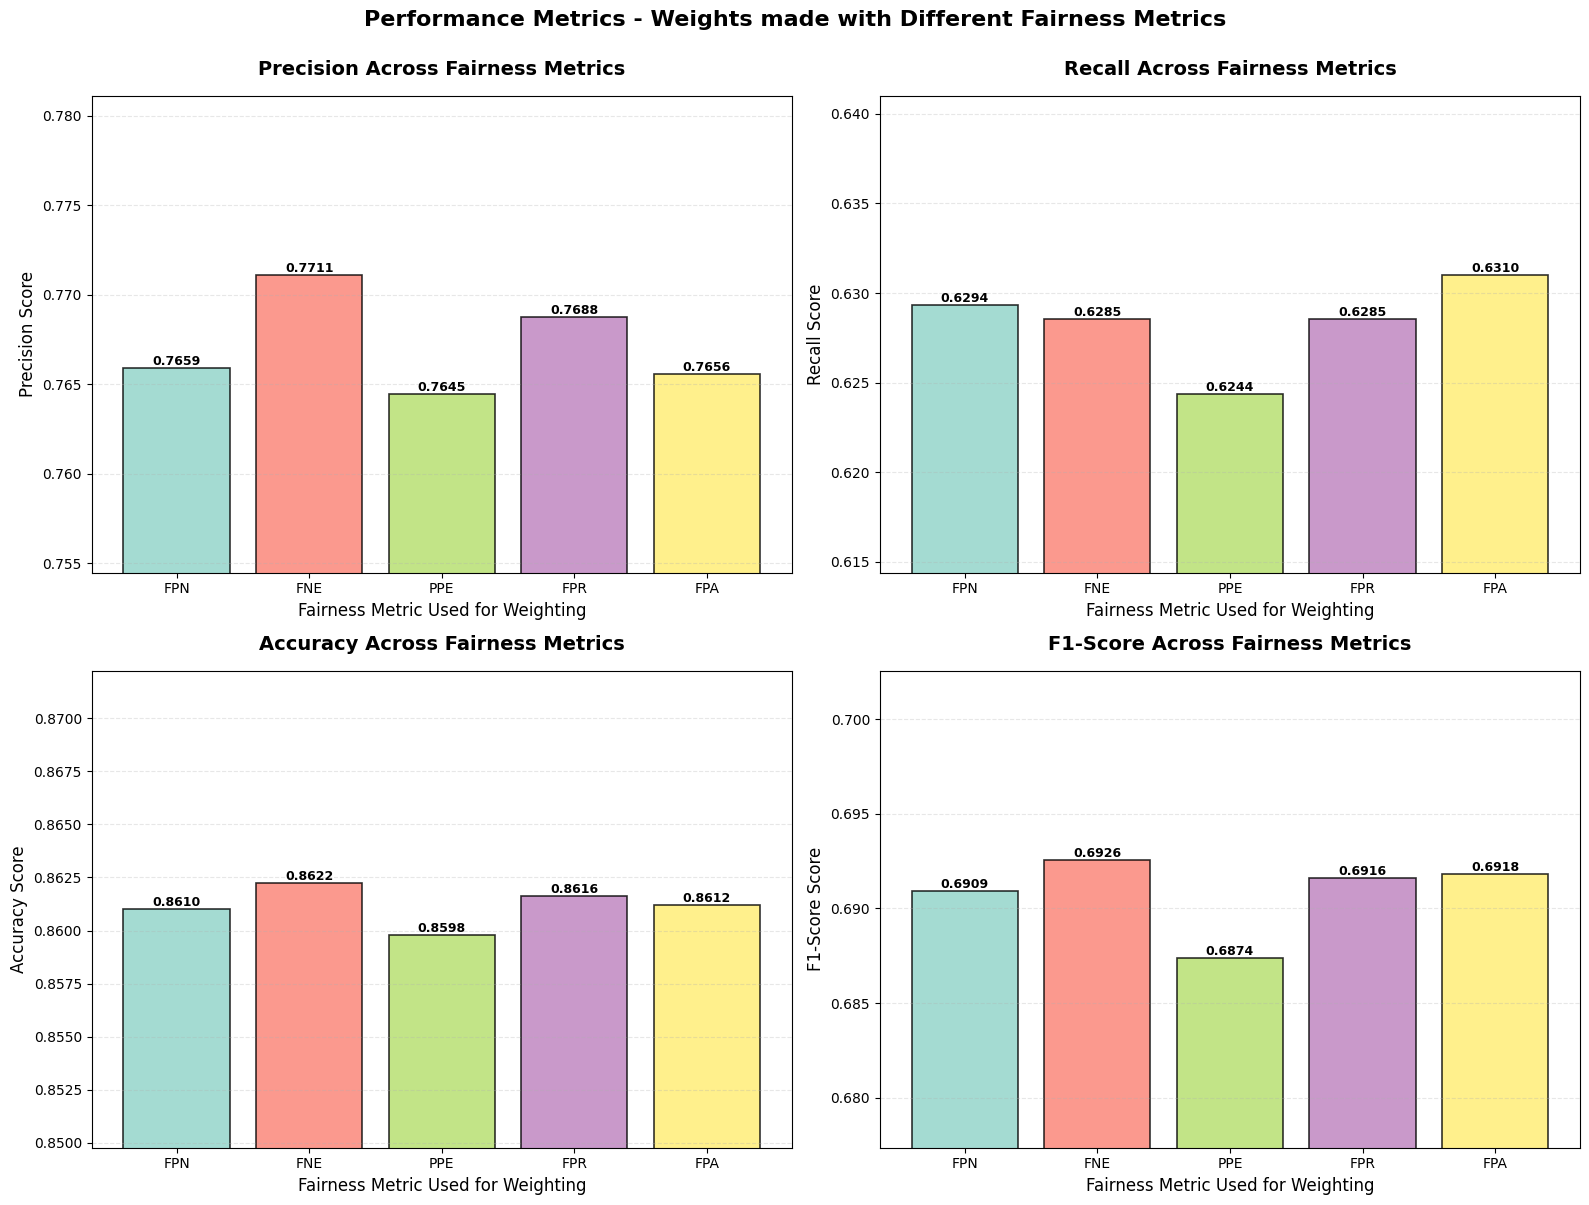

In [ ]:
plot_performance_metrics_bar_chart(performance_per_metric)


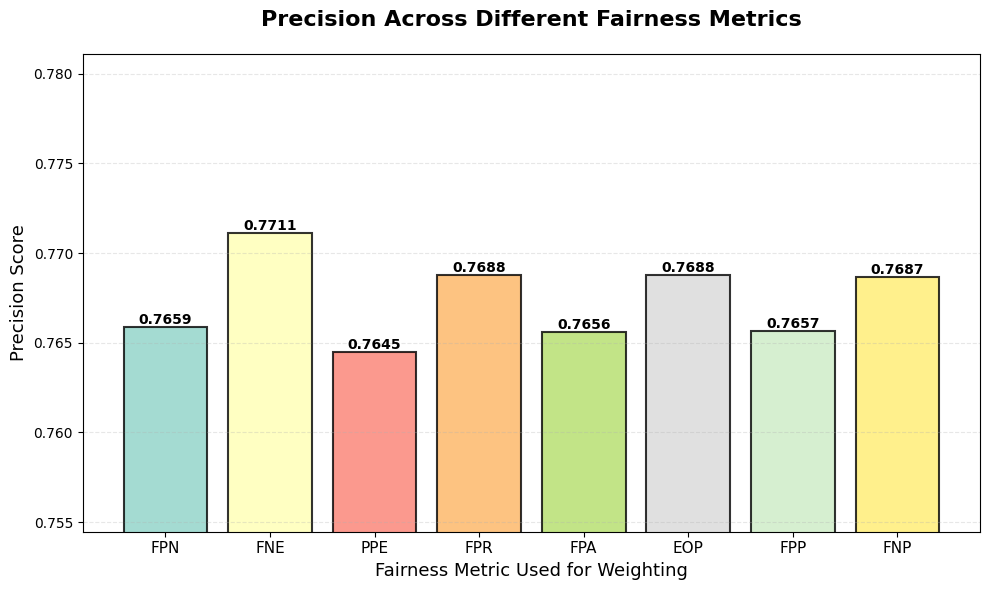

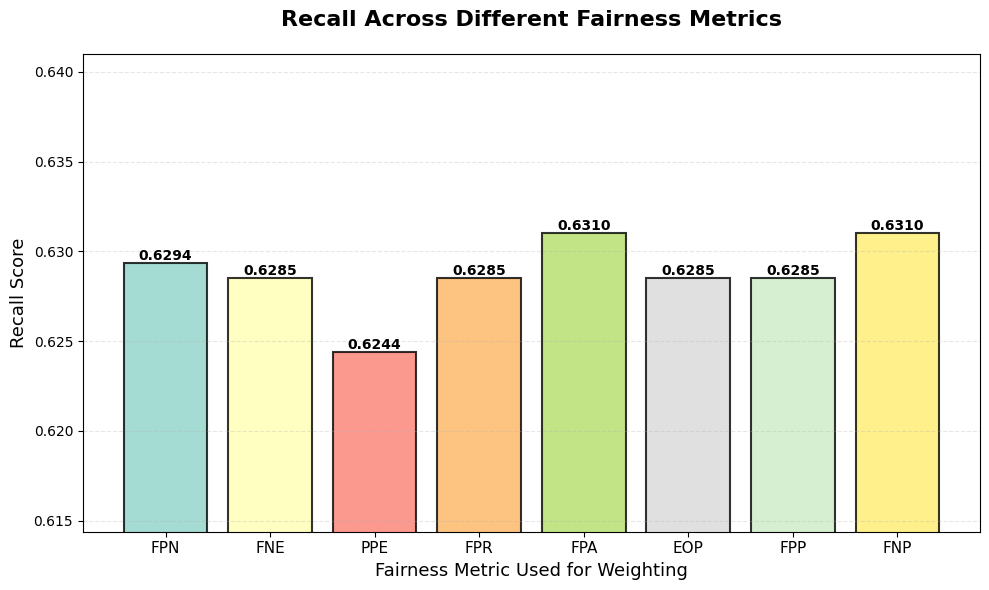

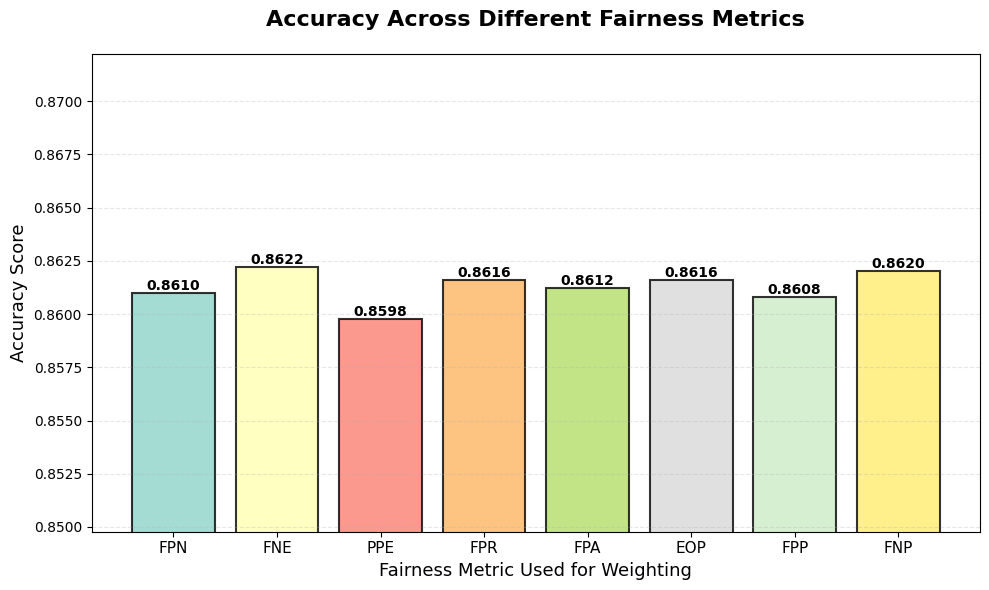

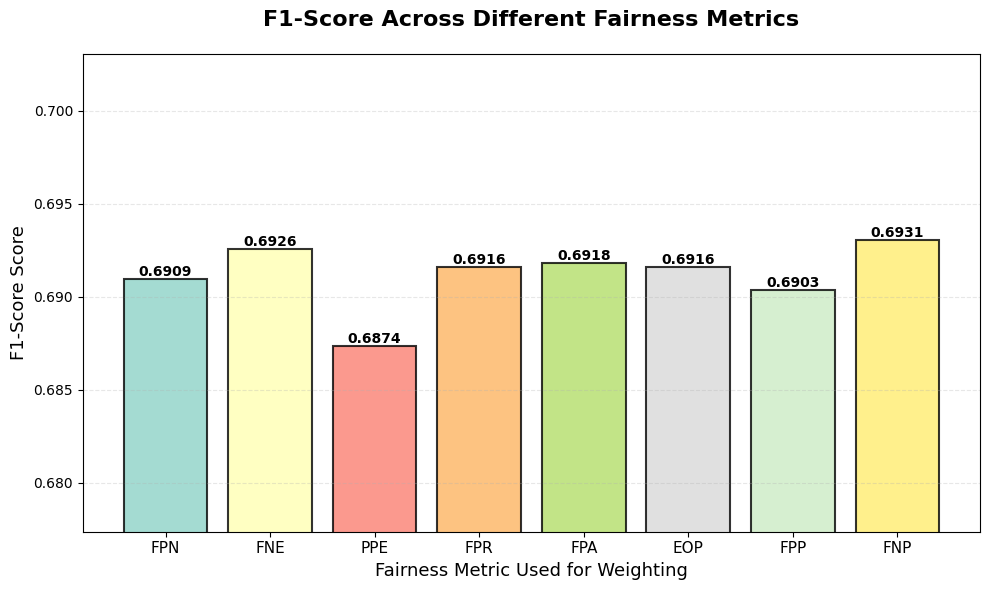

In [ ]:
plot_performance_metrics_individual(performance_per_metric)

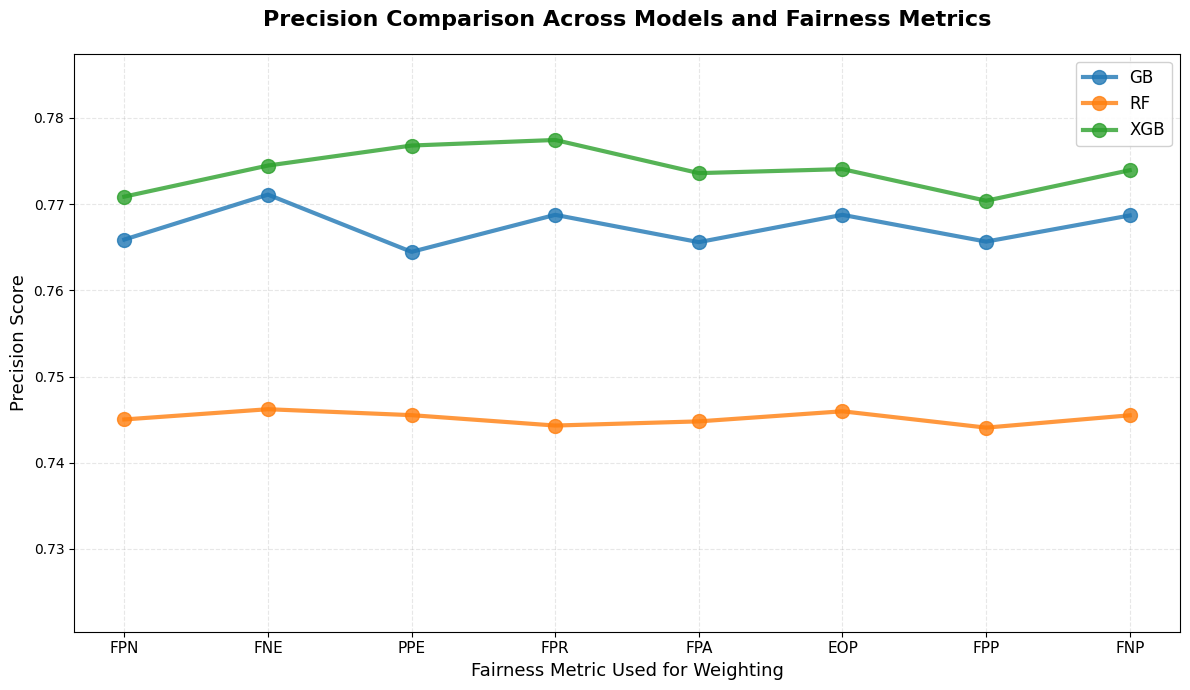

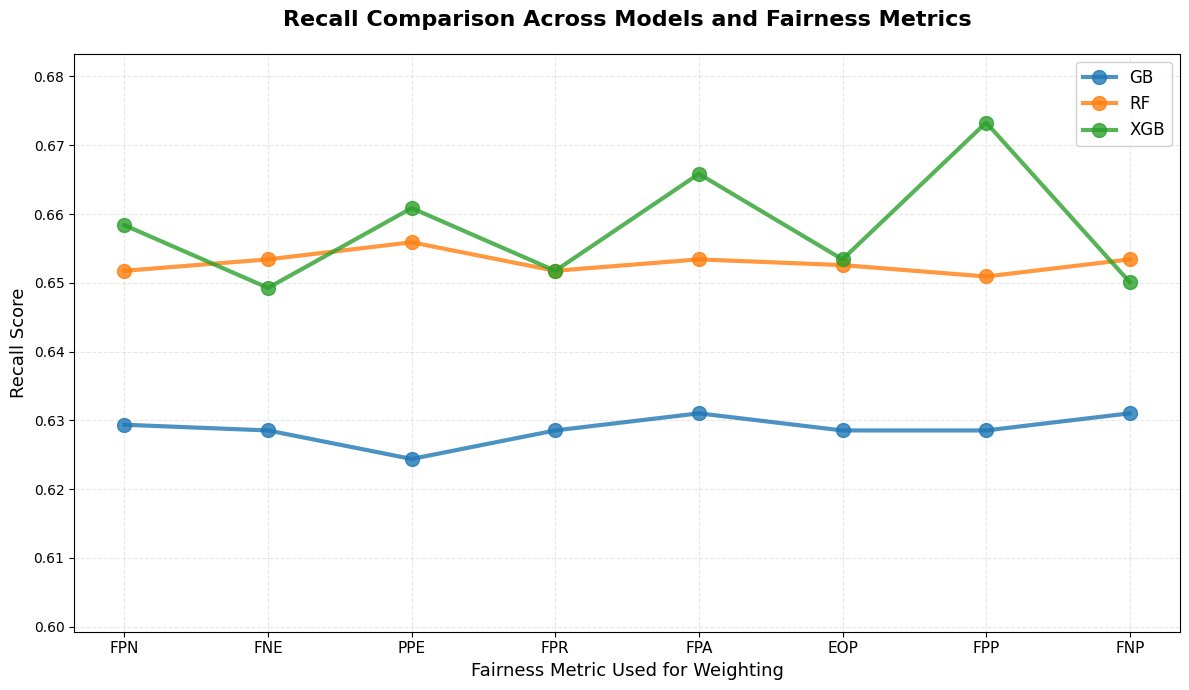

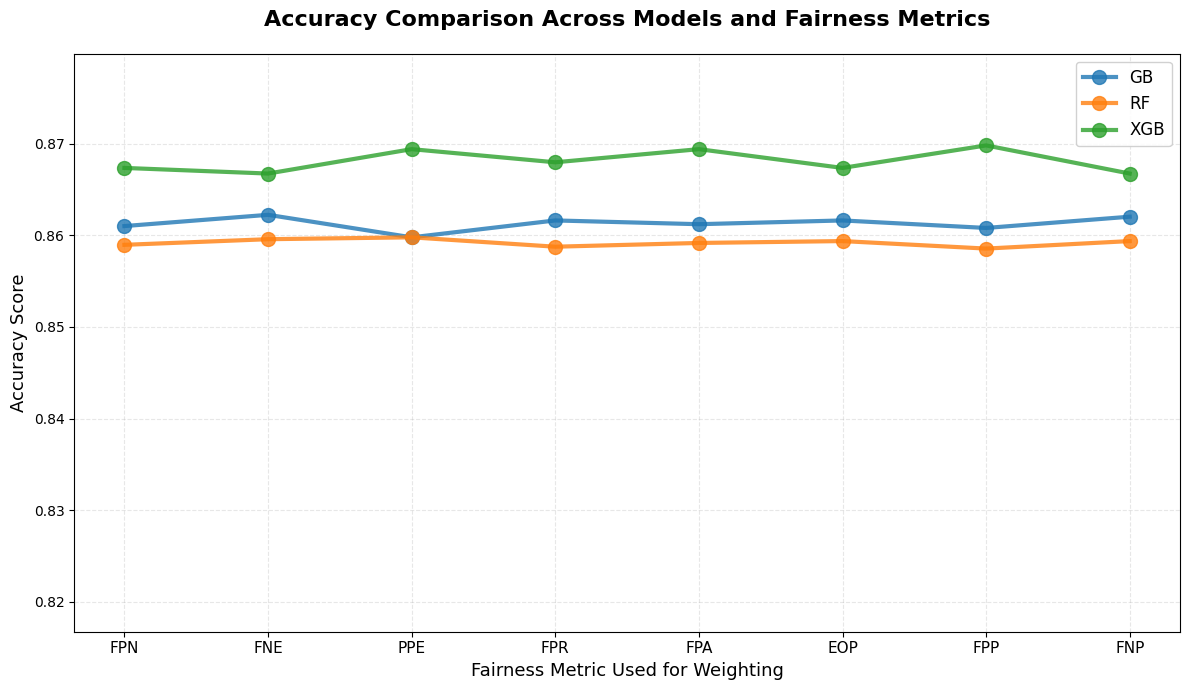

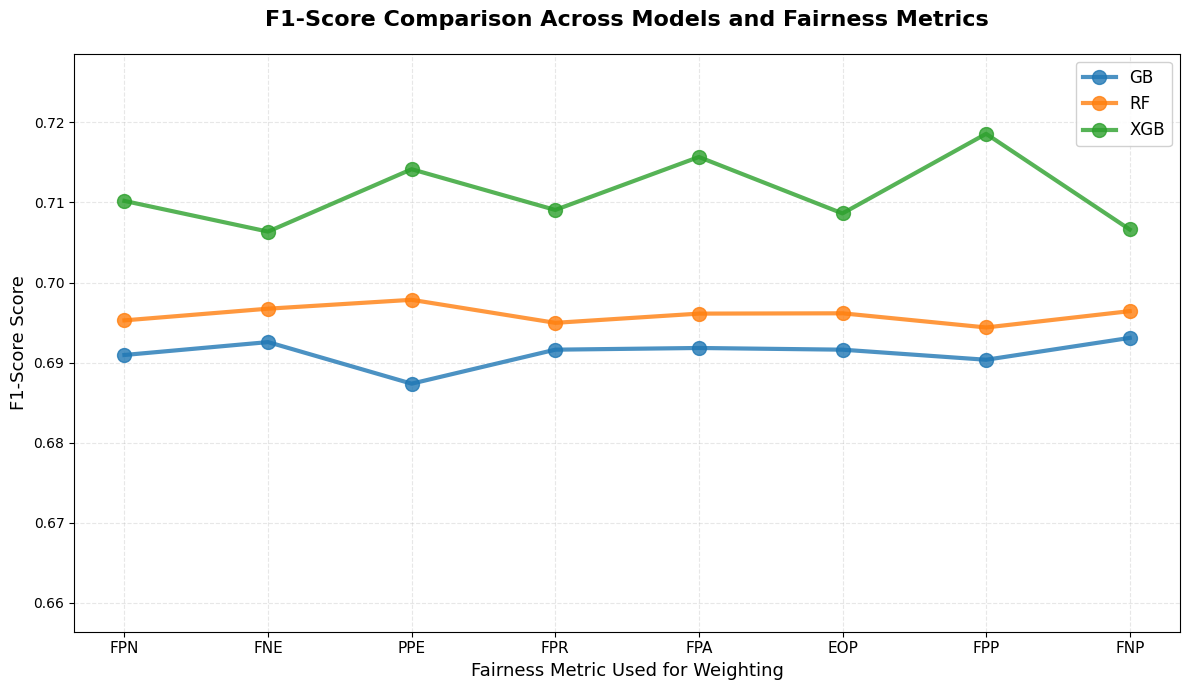

In [ ]:
plot_performance_metrics_individual_models(performance_per_metric_model)


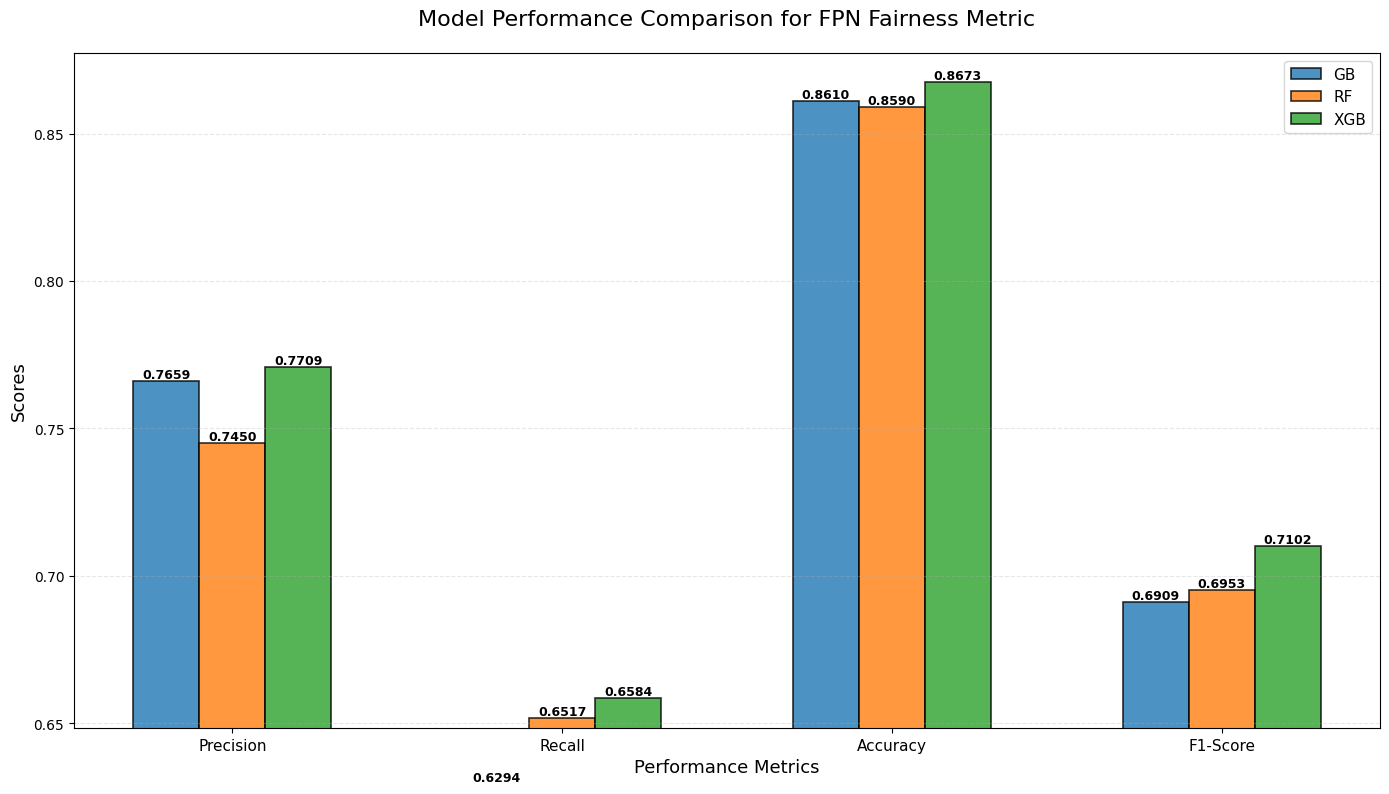

In [ ]:
plot_performance_metrics_comparison_models(performance_per_metric_model, fairness_metric='fpn')

## Before/After Comparison - FPN Fairness Metric

Comparing model performance before reweighting (baseline) vs after reweighting with FPN metric

In [ ]:
[performance_per_metric_model['RF'][fairness_metric]]

[(0.7450236966824645,
  0.6517412935323383,
  0.8589559877175026,
  0.6952675807164971)]

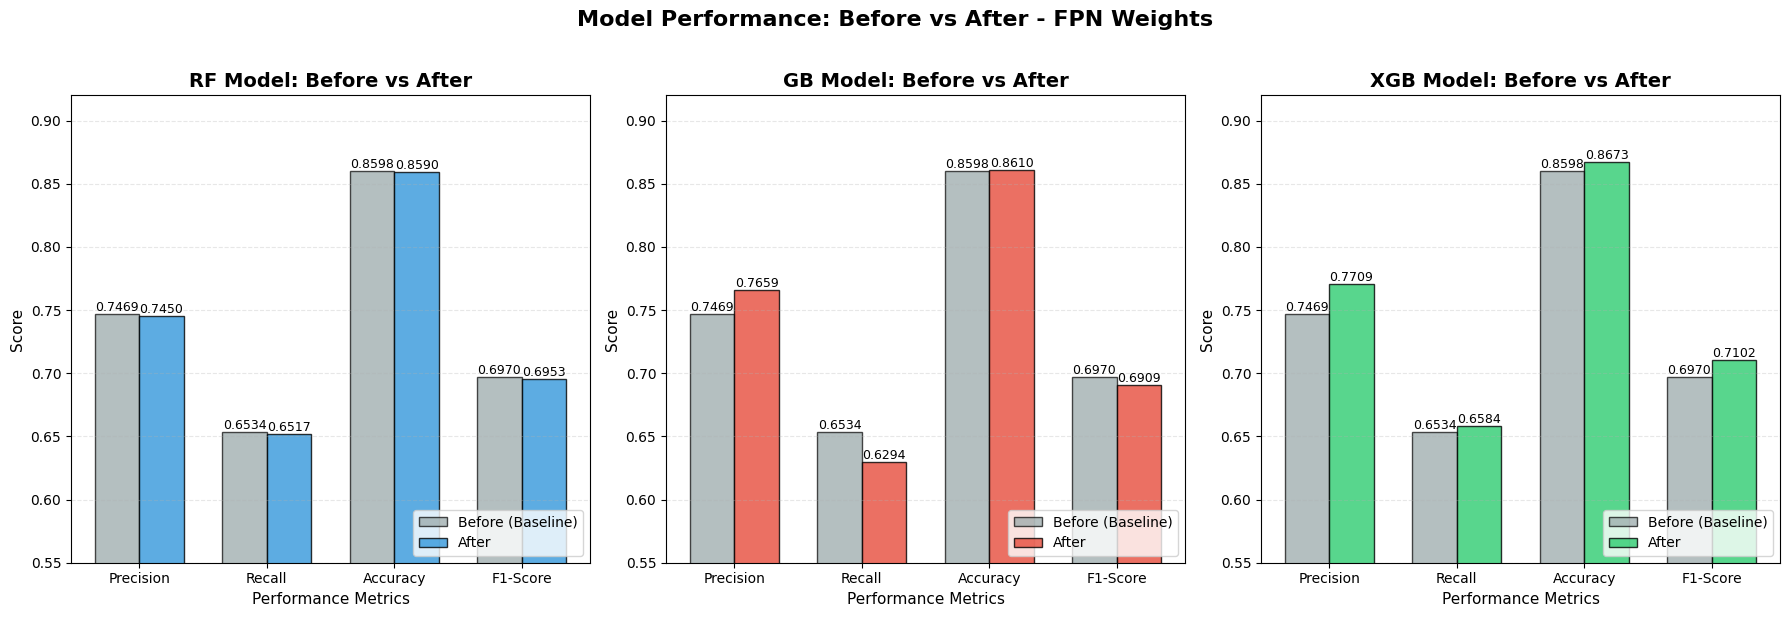

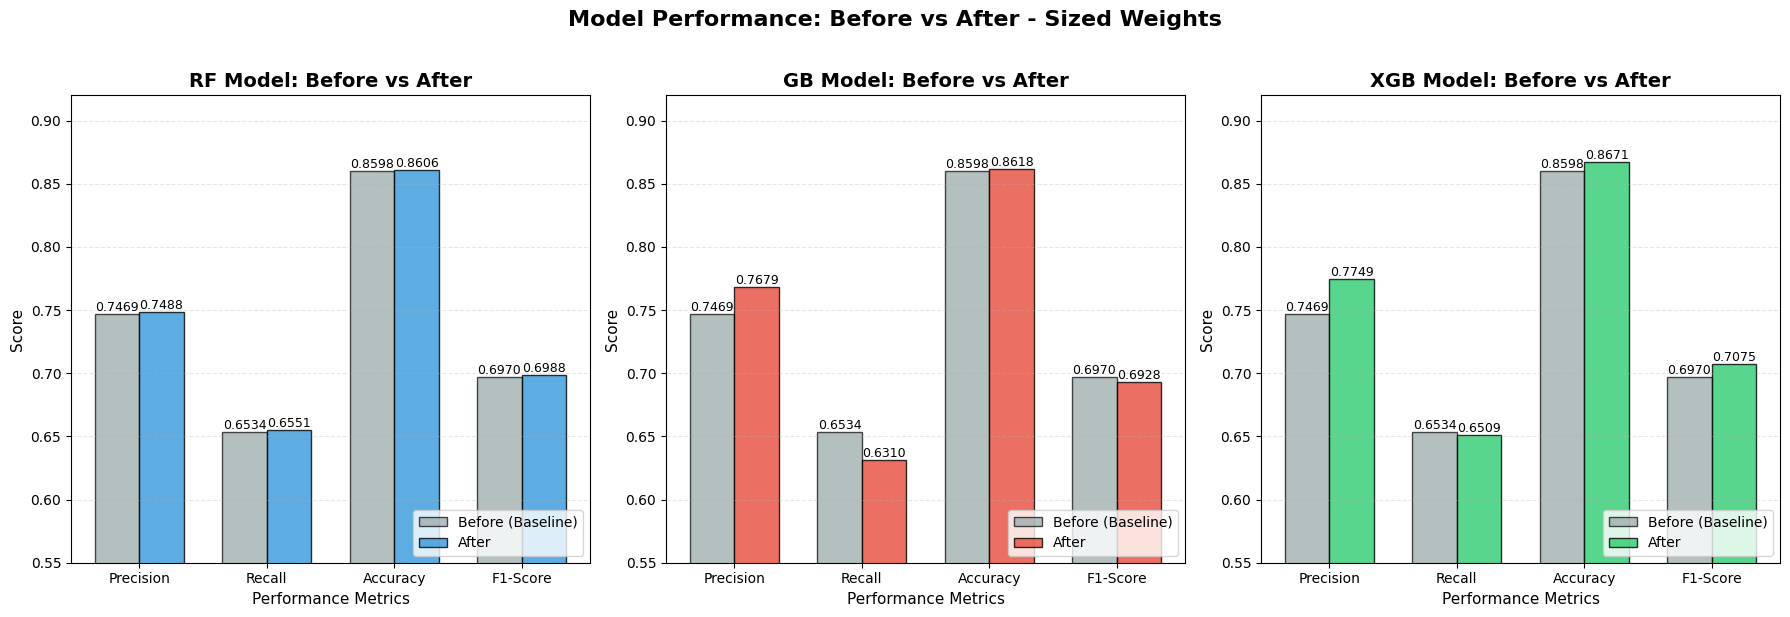

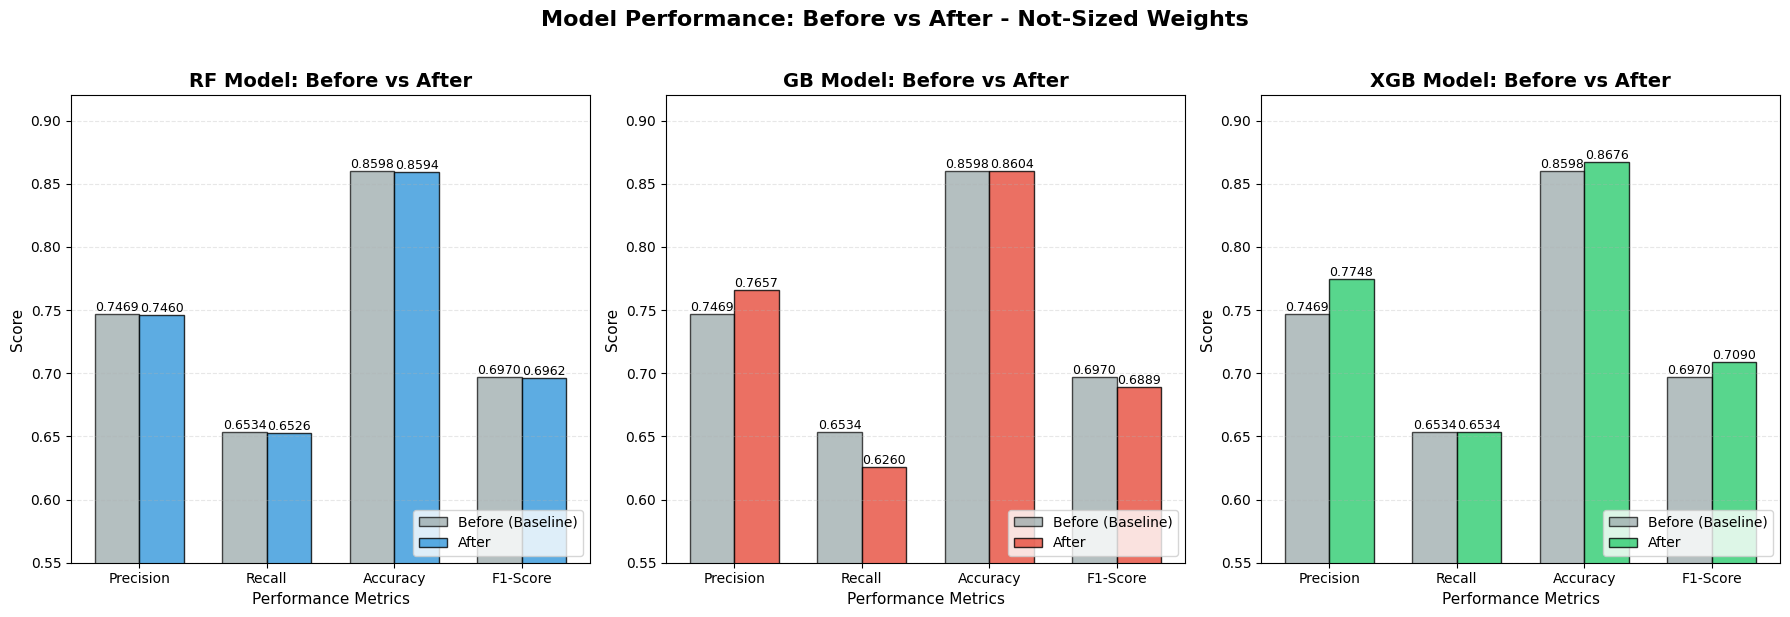

In [ ]:
# Baseline performance (before reweighting)}
# Precision: 0.7469194312796209, Recall: 0.6533996683250415, Accuracy: 0.8597748208802457, F1: 0.6970367094206104
baseline_performance = {
    'RF': [0.7469, 0.6534, 0.8598, 0.6970],  # Precision, Recall, Accuracy, F1
    'GB': [0.7469, 0.6534, 0.8598, 0.6970],
    'XGB': [0.7469, 0.6534, 0.8598, 0.6970]
}

# Define all three after_performance variants with descriptive names
fairness_metric = 'fpn'
after_performance_variants = {
    'FPN Weights': {
        'RF': list(performance_per_metric_model['RF'][fairness_metric]),
        'GB': list(performance_per_metric_model['GB'][fairness_metric]),
        'XGB': list(performance_per_metric_model['XGB'][fairness_metric])
    },
    'Sized Weights': {
        'RF': list(performance_per_model_wsized['RF']),
        'GB': list(performance_per_model_wsized['GB']),
        'XGB': list(performance_per_model_wsized['XGB'])
    },
    'Not-Sized Weights': {
        'RF': list(performance_per_model_wnotsized['RF']),
        'GB': list(performance_per_model_wnotsized['GB']),
        'XGB': list(performance_per_model_wnotsized['XGB'])
    }
}

plot_before_after_performance_bars(baseline_performance, after_performance_variants)

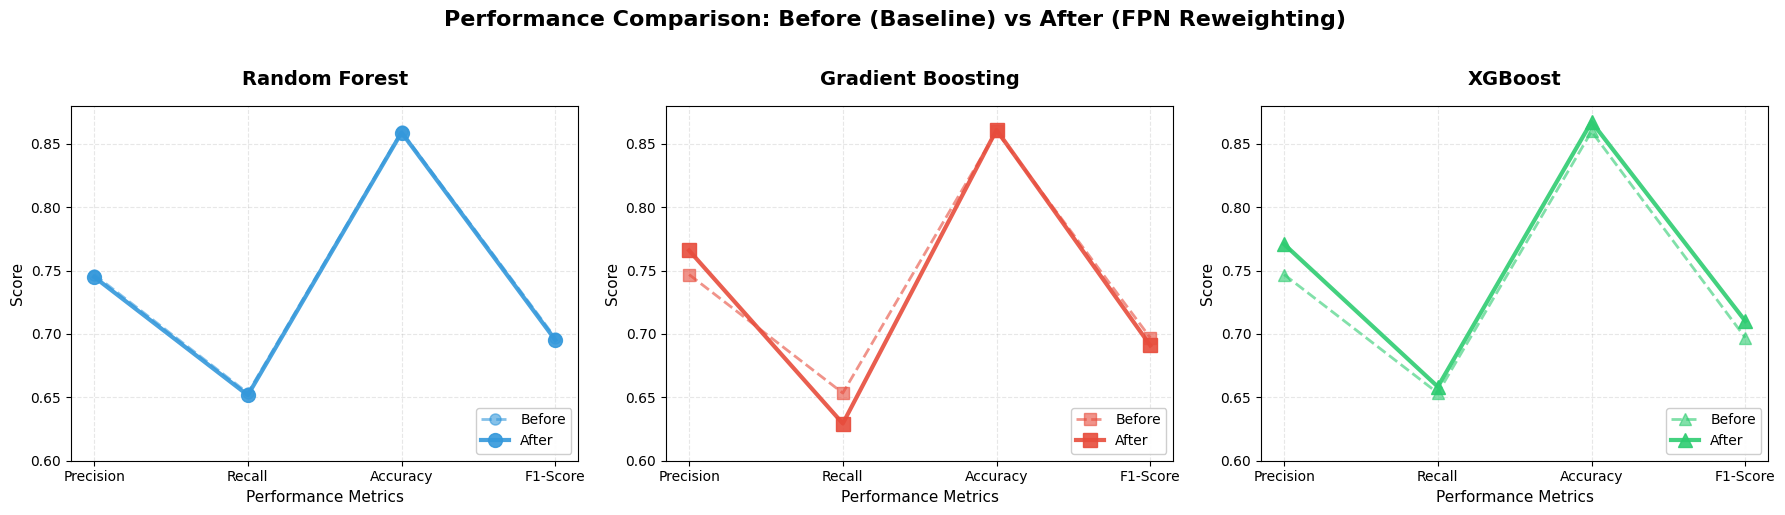

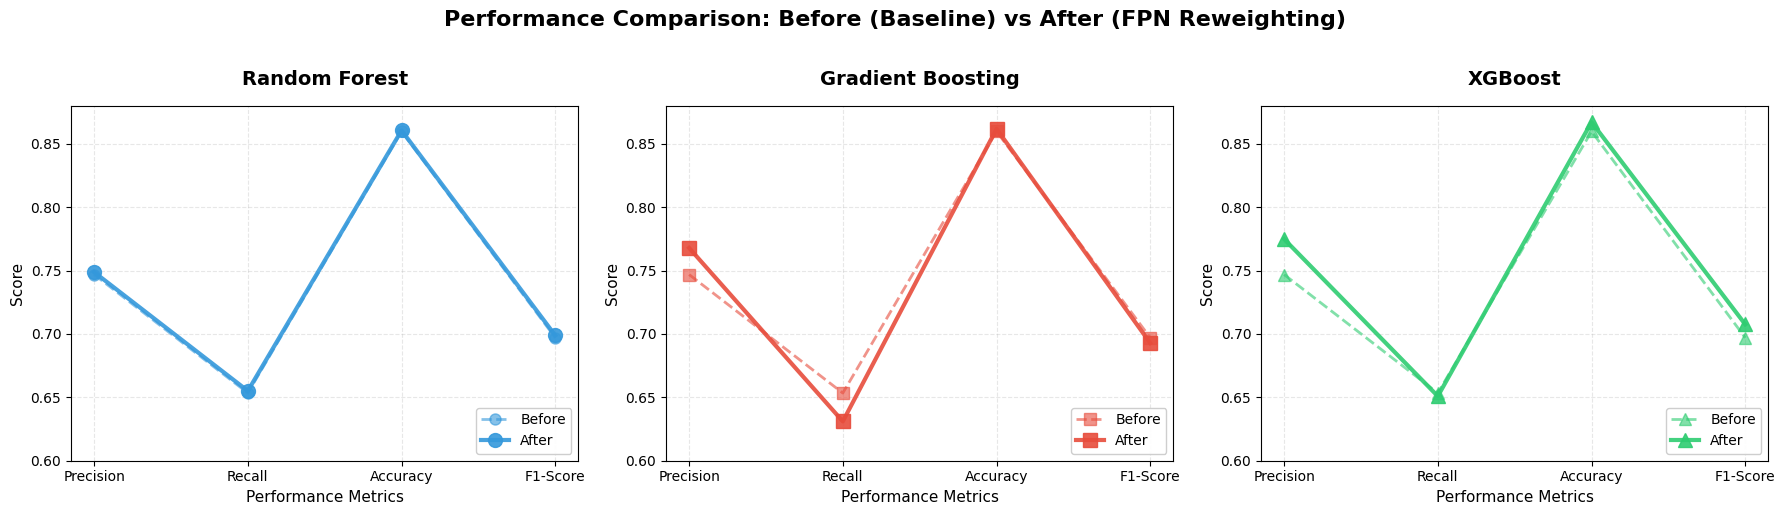

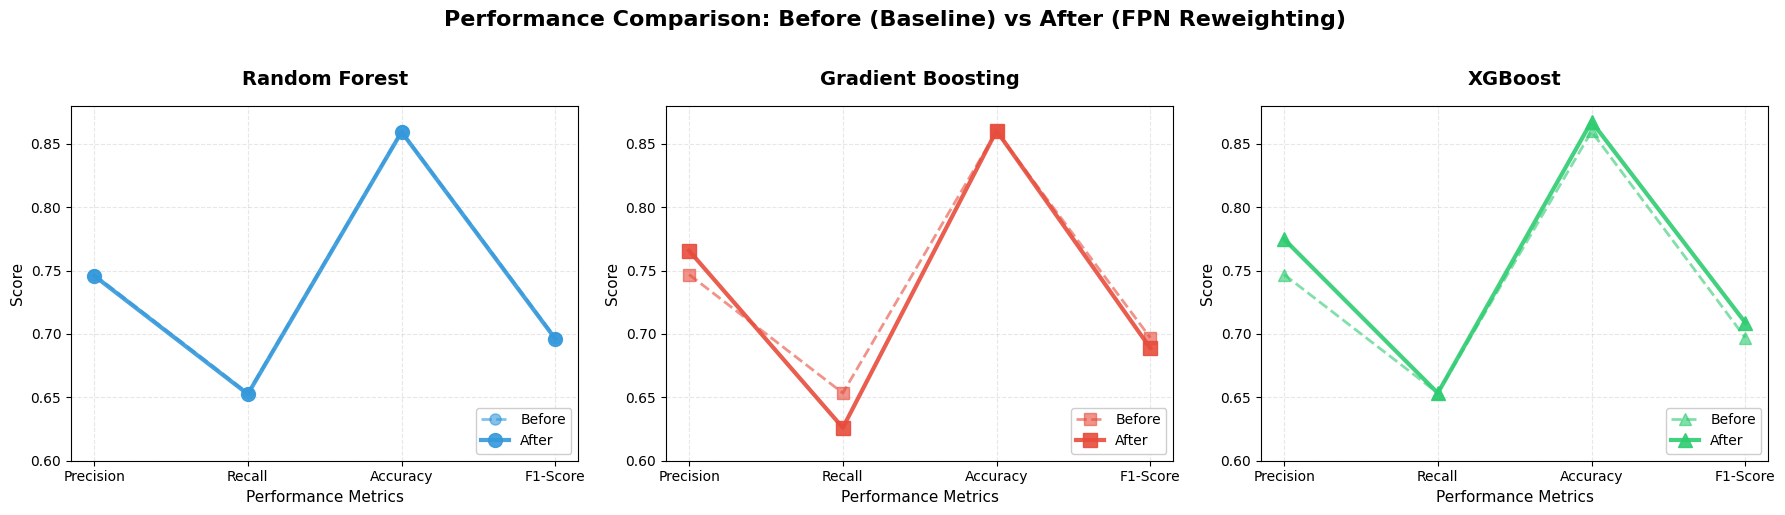

In [ ]:
# Create 3 separate plots, one for each model
plot_before_after_performance_lines(baseline_performance, after_performance_variants)

In [ ]:
# Performance change (delta) visualization - showing improvement or degradation

plot_before_after_performance_diff(baseline_performance, after_performance_variants)

NameError: name 'plot_before_after_performance_diff' is not defined

In [ ]:
# Print first n weights that are not equal to 1.0 (i.e. reweighted samples)
def first_n_weights(weights):
    n = 0
    for w in weights:
        if float(w) != 1.0:
            print(w)
            n+=1
        if n == 100:
            break

---

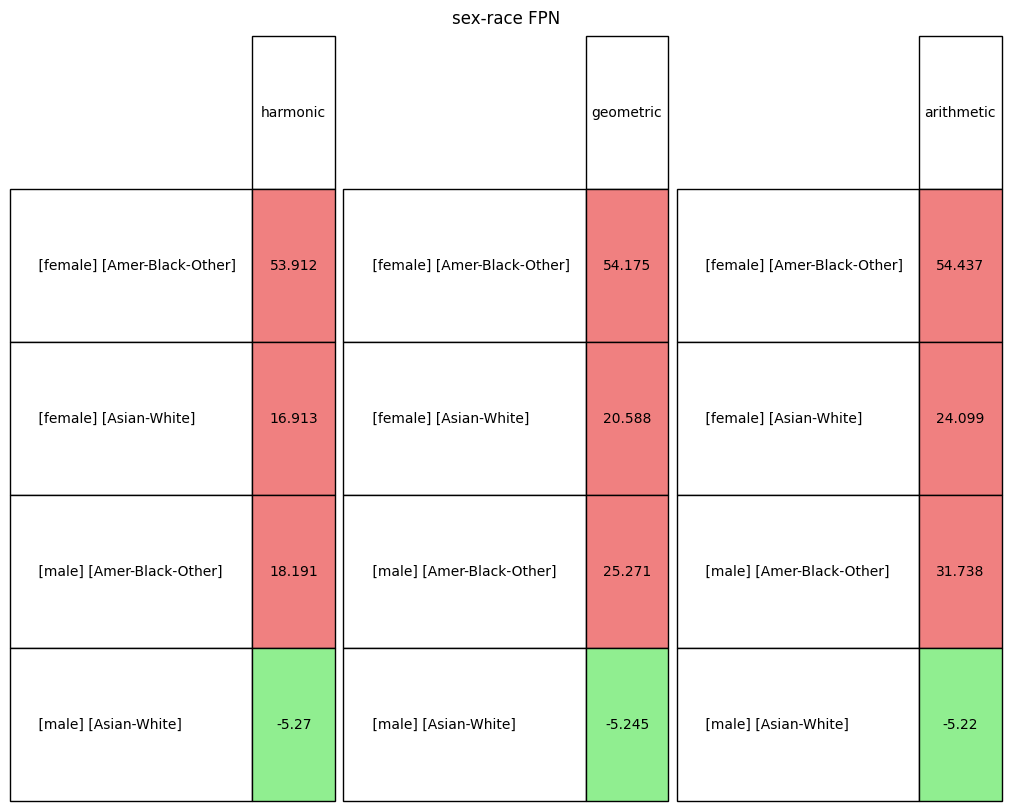

{'00': 99.99999999999999,
 '01': 15.836526181353772,
 '10': 9.329268292682908,
 '11': -6.393389438123403}

'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }

XGB: {'00': 20.5762987012987,
  '01': 18.601825818320656,
  '10': 30.82368082368083,
  '11': -6.561270689527191}

---

# Compute Fairness Metrics and Penalty After Reweighting (Model 2)

To compute penalties for Model 2, we need:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:

print(weights_per_metric['ppe'])
# Train Model 2 with weights and get predictions on test set
sensible_attribute = 'sex-race'
# model_2 = RandomForestClassifier(random_state=1234).fit(
#     X_train['sex-race'], 
#     y_train['sex-race'], 
#     sample_weight = weights_per_metric['ppe']  # Change this to use different weights
# )

import xgboost as xgb
# Convert string combinations to numeric codes for BOTH train and val
X_train_numeric = X_train['sex-race'].copy()
X_train_numeric['sex-race'] = X_train_numeric['sex-race'].astype('category').cat.codes

X_test_numeric = X_test['sex-race'].copy()
X_test_numeric['sex-race'] = X_test_numeric['sex-race'].astype('category').cat.codes

model_2 = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
model_2.fit(X_train_numeric, y_train['sex-race'], sample_weight=weights_per_metric['fpn'])
y_pred_model2_test = model_2.predict(X_test_numeric)

[0.72507319 0.72507319 1.59066742 ... 0.72507319 1.44796021 0.72507319]


In [93]:
attrs = ['sex', 'race', 'sex-race']

df_original = pd.read_csv(dataset_path)

fairness_metrics_model2 = {}
count_groups_model2 = {}

# First, compute metrics for the COMBINED attribute (actual values)
# Create df with combined column for indexing
df_combined = df_original.copy()


for attr in attrs:
    individual_attrs = sensible_attribute.split('-')
    if len(attr) > 1:
        df_original[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df_combined[col] for col in individual_attrs])
    # DO I NEED TO DO A DROP HERE?

    
    sensible_indexes_individual = df_original[attr].loc[list(X_test[attr].index)]
    cm_dict_individual = compute_cm_group(
      df_original, attr, sensible_indexes_individual,
      y_pred_model2_test, y_test[attr], X_test[attr], target_variable_labels
    )
    
    fairness_metrics_model2[attr] = {}
    for m in fair_metrics:
      fairness_metrics_model2[attr][m], count_groups_model2[attr] = \
        compute_fairness_metrics_and_counts(cm_dict_individual, m, attr, mapping, dataset_path)

In [94]:
fairness_metrics_model2

{'sex': {'FPN': {0: 0.2920353982300885, 1: 0.3794392523364486}},
 'race': {'FPN': {1: 0.38422818791946306, 0: 0.1346153846153846}},
 'sex-race': {'FPN': {'01': 0.3163265306122449,
   '00': 0.13333333333333333,
   '11': 0.39759036144578314,
   '10': 0.13513513513513514}}}

In [95]:
fairness_metrics_model2

{'sex': {'FPN': {0: 0.2920353982300885, 1: 0.3794392523364486}},
 'race': {'FPN': {1: 0.38422818791946306, 0: 0.1346153846153846}},
 'sex-race': {'FPN': {'01': 0.3163265306122449,
   '00': 0.13333333333333333,
   '11': 0.39759036144578314,
   '10': 0.13513513513513514}}}

In [96]:
compute_penalty_2(fairness_metrics_model2, df_combined, 'sex', 'race', m)

({'00': 27.64790764790765,
  '01': 4.677174561765943,
  '10': 31.99973372387165,
  '11': -4.130666404728775},
 {'00': 32.752887629474216,
  '01': 5.567114844995359,
  '10': 40.20707430953282,
  '11': -4.128618912021405},
 {'00': 37.49767318175774,
  '01': 6.448746586130335,
  '10': 47.42382407580645,
  '11': -4.126571459573332})